In [6]:
# Standard library imports
import os
import random
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cProfile
import pstats

# Configure matplotlib
plt.style.use('fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

In [7]:
from src.seq_embedder import SeqEmbedder
def test_gauge_fixing(theta_series, theta_fixed_series, L, alphabet, num_seqs=100, embedder=None):
    features = list(theta_series.index)
    
    # Check that gauge matches for every sequence
    if embedder is None:
        embedder = SeqEmbedder(features=features, L=L)

    # Check that gauge matches for every sequence
    for _ in range(num_seqs):
        
        # Choose a random sequence
        seq = ''.join(np.random.choice(alphabet, size=L))
        
        # Embed the sequence
        x = embedder.embed(seq)
        
        f = x@theta_series
        f_fixed = x@theta_fixed_series
        
        # Check that the two function values are close      
        assert np.isclose(f, f_fixed), f'{f=}\n{f_fixed=}'
        
    print(f'Tested {num_seqs} random sequences; all passed.')

In [13]:
from src import get_alphabet
L = 5
alphabet = get_alphabet('dna')
alpha = len(alphabet)
bg_df = pd.DataFrame(index=range(L), columns=alphabet, data=1.0/alpha)

# Create theta_series
from src import get_pairwise_model_features
features = get_pairwise_model_features(L=L, alphabet=alphabet)
embedder = SeqEmbedder(features=features, L=L)
values = np.random.normal(size=len(features))
theta_series = pd.Series(data=values, index=features)
theta_series


((), )          0.708377
((0,), A)       0.047946
((0,), C)       0.681019
((0,), G)       0.653722
((0,), T)       0.510826
                  ...   
((3, 4), GT)    0.452413
((3, 4), TA)    0.312766
((3, 4), TC)   -0.366619
((3, 4), TG)   -0.295966
((3, 4), TT)    1.020582
Length: 181, dtype: float64

In [14]:
from src.fix_hg_gauge_theta_series import fix_hg_gauge_theta_series
theta_fixed_series = fix_hg_gauge_theta_series(theta_series, L=L, alphabet=alphabet, bg_df=bg_df)
theta_fixed_series


((), )          1.648014
((0,), A)       0.322376
((0,), C)      -0.467986
((0,), G)       0.438961
((0,), T)      -0.293351
                  ...   
((3, 4), GT)    0.424004
((3, 4), TA)   -0.106055
((3, 4), TC)   -0.192988
((3, 4), TG)   -0.448835
((3, 4), TT)    0.747878
Length: 181, dtype: float64

In [15]:
# Test gauge fixing
test_gauge_fixing(theta_series=theta_series, theta_fixed_series=theta_fixed_series, L=L, alphabet=alphabet, num_seqs=10, embedder=embedder)

Tested 10 random sequences; all passed.


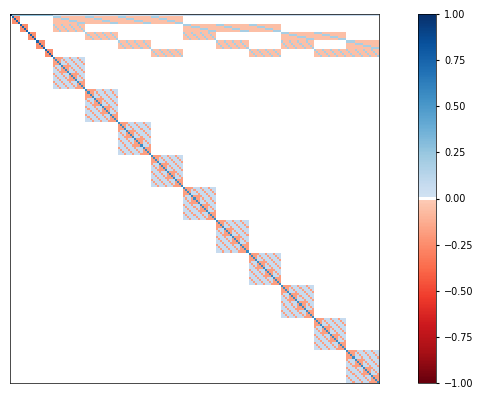

In [16]:
# Visualize gauge fixing matrix
from src.get_hg_projection_matrix import get_hg_projection_matrix
M = get_hg_projection_matrix(features, L, alphabet, bg_df)
M

# Visualize gauge fixing matrix
from src.visualize_matrix import visualize_matrix
visualize_matrix(M, figsize=figsize, show_grid=False)

In [ ]:
from src import get_alphabet
L = 55
alphabet = get_alphabet('protein')
alpha = len(alphabet)
bg_df = pd.DataFrame(index=range(L), columns=alphabet, data=1.0/alpha)

# Create theta_series
from src import get_pairwise_model_features
features = get_pairwise_model_features(L=L, alphabet=alphabet)
embedder = SeqEmbedder(features=features, L=L)
values = np.random.normal(size=len(features))
theta_series = pd.Series(data=values, index=features)
theta_series


In [ ]:
from src.fix_gauge_pairwise_theta_series import fix_gauge_pairwise_theta_series

# Fix gauge of theta_series
with cProfile.Profile() as profiler:
    theta_fixed_series = fix_gauge_pairwise_theta_series(theta_series, p_lc=bg_df.values, alphabet=alphabet, L=L)
stats = pstats.Stats(profiler).strip_dirs().sort_stats('cumulative')
stats.print_stats(10)

# Test gauge fixing
test_gauge_fixing(theta_series=theta_series, theta_fixed_series=theta_fixed_series, L=L, alphabet=alphabet, num_seqs=10, embedder=embedder)

In [ ]:
# Convert to dict
from src.pairwise_theta_series_to_dict import pairwise_theta_series_to_dict
theta_dict = pairwise_theta_series_to_dict(theta_series, alphabet=alphabet, L=L)

# Fix gauge of theta_series
from src.fix_gauge_pairwise_theta_dict import fix_gauge_pairwise_theta_dict
with cProfile.Profile() as profiler:
    theta_fixed_dict = fix_gauge_pairwise_theta_dict(theta_dict, p_lc=bg_df.values)
stats = pstats.Stats(profiler).strip_dirs().sort_stats('cumulative')
stats.print_stats(10)

# Test gauge fixing
test_gauge_fixing(theta_series=theta_series, theta_fixed_series=theta_fixed_series, L=L, alphabet=alphabet, num_seqs=10, embedder=embedder)

In [ ]:
with cProfile.Profile() as profiler:
    test_gauge_fixing(theta_series=theta_series, theta_fixed_series=theta_fixed_series, L=L, alphabet=alphabet, num_seqs=10, embedder=embedder)
stats = pstats.Stats(profiler).strip_dirs().sort_stats('cumulative')
stats.print_stats(10)